## Loading Libraries

In [30]:
import requests
import pandas as pd

import plotly.express as px
import folium

import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
from zipfile import ZipFile
import geopandas as gpd
from urllib.parse import urlencode

In [31]:
citibike_df = pd.read_csv("../Data/citibike/JC/JC2025_Enriched.csv")

### Downloading Data

In [32]:
from posixpath import join

In [33]:
url='https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/citibike/JC/jersey-city-neighborhoods.geojson'

In [34]:
def geojson_downloader(url:str, name:str, path:str)->gpd.GeoDataFrame:
    df = gpd.read_file(url)
    df.to_file(f'{path}/{name}.geojson'),
    driver='GeoJSON'
    print(f'The {name}.geojson was successfully stored in {path}')
    return df


In [35]:
jersey_city=geojson_downloader(
    url=url,name='jercey-city-neighborhoods',path='../Data/citibike/JC'
)

The jercey-city-neighborhoods.geojson was successfully stored in ../Data/citibike/JC


In [40]:
OUTPUT_DIR = "../Data/citibike/"

In [41]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 3.6 KB


In [42]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [43]:
jersey_city = jersey_city.to_crs("EPSG:4326")

In [44]:
citibike_df.shape

(998281, 22)

Matplotlib is building the font cache; this may take a moment.


<Axes: >

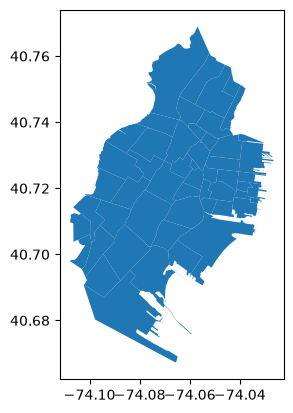

In [45]:
jersey_city.plot()

### Station Level Analysis

### Departures

In [52]:
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()


start_stations.rename(columns= {"start_station_id":'station_id',
        "start_station_name":'station_name',
        "start_lat": 'lat',
        "start_lng": 'lng'},
        inplace=True
                      )

start_stations["activity_type"] = "departure"

start_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC019,Hilltop,40.731169,-74.057574,departure
1,1A5E1E274B2AF0AD,JC019,Hilltop,40.731169,-74.057574,departure
2,EA9928D3C05B8377,JC019,Hilltop,40.731169,-74.057574,departure
3,3C42C367750B9292,JC019,Hilltop,40.731169,-74.057574,departure
4,94D3B0265A7BDE1F,JC019,Hilltop,40.731169,-74.057574,departure


### Arrivals

In [53]:
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()


end_stations.rename(columns= {"end_station_id":'station_id',
        "end_station_name":'station_name',
        "end_lat": 'lat',
        "end_lng": 'lng'},
        inplace=True
                      )

end_stations["activity_type"] = "arrival"
end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC024,Pershing Field,40.742677,-74.051789,arrival
1,1A5E1E274B2AF0AD,JC063,Jackson Square,40.711130,-74.078900,arrival
2,EA9928D3C05B8377,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival
3,3C42C367750B9292,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival
4,94D3B0265A7BDE1F,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival


### Concatinating departures and arrivals

In [54]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)


station_activity_long.head()


,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC019,Hilltop,40.731169,-74.057574,departure
1,1A5E1E274B2AF0AD,JC019,Hilltop,40.731169,-74.057574,departure
2,EA9928D3C05B8377,JC019,Hilltop,40.731169,-74.057574,departure
3,3C42C367750B9292,JC019,Hilltop,40.731169,-74.057574,departure
4,94D3B0265A7BDE1F,JC019,Hilltop,40.731169,-74.057574,departure


In [56]:
station_activity_long['activity_type'].value_counts()

activity_type
departure    998281
arrival      998281
Name: count, dtype: int64

### Data cleaning/aggregation

In [58]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    ).sort_values(by = [ 'activity_type','number_of_rides'], ascending=False)
)

station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
547,JC115,Grove St PATH,40.719410,-74.043090,departure,44984
377,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,departure,25879
451,JC009,Hamilton Park,40.727596,-74.044247,departure,22232
385,HB106,River St & Newark St,40.736722,-74.029007,departure,21383
495,JC066,Newport PATH,40.727224,-74.033759,departure,20641


## Derived Columns

In [60]:
station_summary = station_activity_agg.pivot_table(
    index= [
            "station_id",
            "station_name",
            "lat",
            "lng"
     ],
     columns= "activity_type",
     values = "number_of_rides",
     fill_value=0

).reset_index()

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0


In [61]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.sort_values(by= 'net_departures', ascending=True).head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0
15,HB102,Hoboken Terminal - River St & Hudson Pl,40.736068,-74.029127,18073.0,16757.0,34830.0,-1316.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0
96,5297.02,Vesey Pl & River Terrace,40.715338,-74.016584,469.0,0.0,469.0,-469.0


In [62]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["lng"],
        station_summary["lat"]
    ),
    crs="EPSG:4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722)


<Axes: >

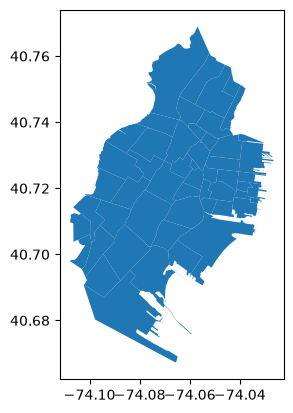

In [64]:
jersey_city.plot()

<Axes: >

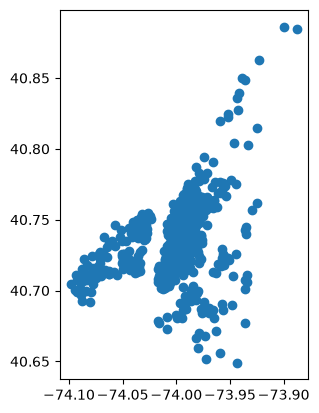

In [65]:
station_gdf.plot()

In [66]:
station_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 488 entries, 0 to 487
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   station_id        488 non-null    str     
 1   station_name      488 non-null    str     
 2   lat               488 non-null    float64 
 3   lng               488 non-null    float64 
 4   total_arrivals    488 non-null    float64 
 5   total_departures  488 non-null    float64 
 6   total_activity    488 non-null    float64 
 7   net_departures    488 non-null    float64 
 8   geometry          488 non-null    geometry
dtypes: float64(6), geometry(1), str(2)
memory usage: 34.4 KB


In [67]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 3.6 KB


In [68]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20370.0,40727.0,13.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,19982.0,40124.0,-160.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


## Neigborhood Level Analysis

### Route Level

In [71]:
route_summary = (
    citibike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

route_summary["route"] = (
    route_summary["start_station_name"] +
    " → " +
    route_summary["end_station_name"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,Hoboken Terminal - Hudson St & Hudson Pl → Hob...
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,McGinley Square → Bergen Ave & Sip Ave
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,Grove St PATH → Marin Light Rail
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,Marin Light Rail → Grove St PATH
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,Grove St PATH → Liberty Light Rail


In [72]:
route_summary["route"] = (
    route_summary["start_station_id"] +
    " → " +
    route_summary["end_station_id"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,HB101 → JC105
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,JC055 → JC109
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,JC115 → JC013
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,JC013 → JC115
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,JC115 → JC052


In [73]:
top_routes = route_summary.head(20)

top_routes[
    [
        "route",
        "number_of_rides"
    ]
]

,route,number_of_rides
83,HB101 → JC105,4559
5583,JC055 → JC109,4306
8709,JC115 → JC013,4131
3937,JC013 → JC115,3831
8723,JC115 → JC052,3750
8445,JC109 → JC055,3609
5395,JC052 → JC115,3605
8154,JC105 → HB101,3257
4570,JC023 → JC115,3175
3788,JC009 → JC115,2998


#### Top Lines Visualization

In [75]:
import folium

top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 8

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

In [83]:
print("Station CRS:", station_gdf.crs)
print("Neighborhood CRS:", jersey_city.crs)

Station CRS: EPSG:4326
Neighborhood CRS: EPSG:4326


In [84]:
station_gdf = station_gdf.to_crs("EPSG:4326")

In [85]:
jersey_city.columns

Index(['cartodb_id', 'area_sq_ft', 'acres', 'area', 'neighborhood', 'color',
       'lon', 'lat', 'geometry'],
      dtype='str')

In [86]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20370.0,40727.0,13.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,19982.0,40124.0,-160.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


In [87]:
print(station_gdf.shape)
print(station_neighborhood.shape)

(488, 9)
(79, 18)


#### Stations Number

In [88]:
print("All stations:", len(station_gdf))
print("Stations inside Jersey City neighborhoods:", len(station_neighborhood))

All stations: 488
Stations inside Jersey City neighborhoods: 79


#### Aggregating station activity by neighborhood

In [91]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborhood', as_index=False)
    .agg(
        number_of_stations=("station_id", "nunique"),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity["avg_activity_per_station"] = (
    neighborhood_activity["total_activity"] /
    neighborhood_activity["number_of_stations"]
)

neighborhood_activity = neighborhood_activity.sort_values(
    "total_activity",
    ascending=False
)

neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,96144.0,98853.0,194997.0,-2709.0,32499.500000
17,Palus Hook,6,59496.0,59160.0,118656.0,336.0,19776.000000
14,Newport,2,39350.0,39402.0,78752.0,-52.0,39376.000000
10,Journal Square,3,32970.0,32560.0,65530.0,410.0,21843.333333
4,Hamilton Park,2,31729.0,31922.0,63651.0,-193.0,31825.500000


<Axes: >

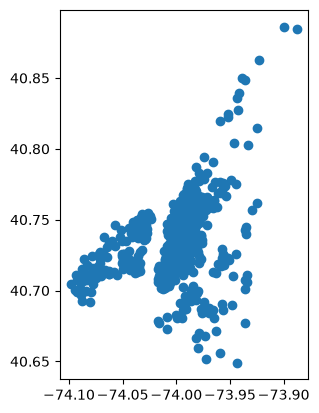

In [92]:
station_gdf.plot()

#### Creating Center Point for the Map

In [95]:
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng

(np.float64(40.734012258630905), np.float64(-74.00137516113631))

##### Visualizing Each Station as a Point

In [96]:
station_point_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

#### Merging Neighborhood Metrics Back to Polygons

In [100]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how="left"
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,12.0,9.0,21.0,3.0,21.0000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,30845.0,30730.0,61575.0,115.0,10262.5000
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,6142.0,6045.0,12187.0,97.0,761.6875


#### Missing Values

In [102]:
activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborhood',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Port Liberte,1.0,12.0,9.0,21.0,21.0000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.0000
2,Hackensack,0.0,0.0,0.0,0.0,0.0000
3,Lafayette,6.0,30845.0,30730.0,61575.0,10262.5000
4,Jackson Hill,16.0,6142.0,6045.0,12187.0,761.6875


## Choropleth Map

### creating a helper function

In [104]:
def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col="neighborhood"
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )

    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)

    folium.GeoJson(
        gdf,
        name="Neighborhood Boundaries",
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            aliases=[
                "Neighborhood:",
                f"{legend_name}:"
            ],
            localize=True
        ),
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "black",
            "weight": 1
        }
    ).add_to(choropleth_map)

    folium.LayerControl().add_to(choropleth_map)

    return choropleth_map

#### Visualizing Total Activity by Neighborhood

In [107]:
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_activity",
    legend_name="Total Citi Bike Activity",
    neighborhood_col="neighborhood"
)

total_activity_map

#### By Number of Stations

In [109]:
station_count_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="number_of_stations",
    legend_name="Number of Citi Bike Stations",
    neighborhood_col="neighborhood"
)

station_count_map

#### By Average Activity per Station

In [111]:
avg_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="avg_activity_per_station",
    legend_name="Average Activity per Station",
    neighborhood_col="neighborhood"
)

avg_activity_map

#### By Total Departures

In [112]:
departures_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_departures",
    legend_name="Total Departures",
    neighborhood_col="neighborhood"
)

departures_map

#### By Total Arrivals

In [115]:
arrivals_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_arrivals",
    legend_name="Total Arrivals",
    neighborhood_col="neighborhood"
)

arrivals_map